# AI Model Failure Detection and Explainability System

---

### Project Information

- **Author:** Rishikesh Singh
- **Phase:** Day 1 — Baseline Model & Failure Analysis
- **Goal:** Identify and explain machine learning model failures using Explainable AI (XAI).

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

## 1.Data Loading and Understanding.

In [2]:
data_path = "/Users/rishikeshsingh/anaconda_projects/AI_Model_Failure_Detection/ai-model-failure-detection/data/dataset.csv"
df = pd.read_csv(data_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Exploratory Data Analysis (EDA).

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

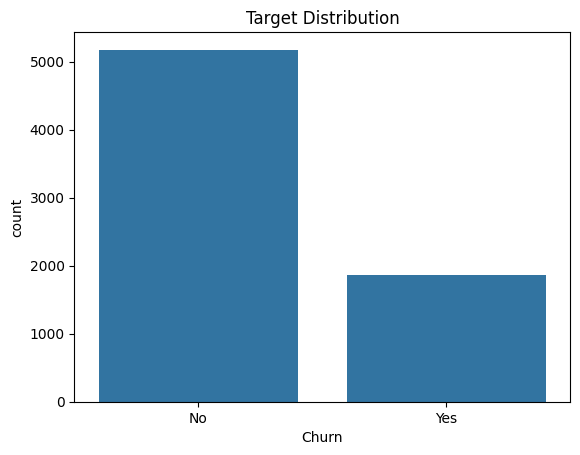

In [5]:
sns.countplot(x='Churn', data=df)
plt.title("Target Distribution")
plt.show()

## 3.Data Preprocessing.

In [6]:
df = df.drop(columns=['customerID'], errors='ignore')

X = df.drop(columns=['Churn'])
y = df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [7]:
cat_cols = X.select_dtypes(include='object').columns

le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

y = LabelEncoder().fit_transform(y)  # 0 = No, 1 = Yes

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 19)
Test shape: (1409, 19)


## 4.Baseline Model Training - Logistic Regression.

In [9]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)

/Users/rishikeshsingh/anaconda_projects/AI_Model_Failure_Detection/ai-model-failure-detection/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## 5.Model Evaluation.

In [10]:
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:,1]

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

roc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_score)

Confusion Matrix:
 [[750 285]
 [ 78 296]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.72      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC Score: 0.8377354103696815


In [11]:
print("Train target distribution:", np.bincount(y_train))
print("Test target distribution:", np.bincount(y_test))

Train target distribution: [4139 1495]
Test target distribution: [1035  374]


## 6.Model Interpretation.

/var/folders/rt/48gpknks5mlc888bjxc5dfx00000gn/T/ipykernel_1520/273070499.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm')


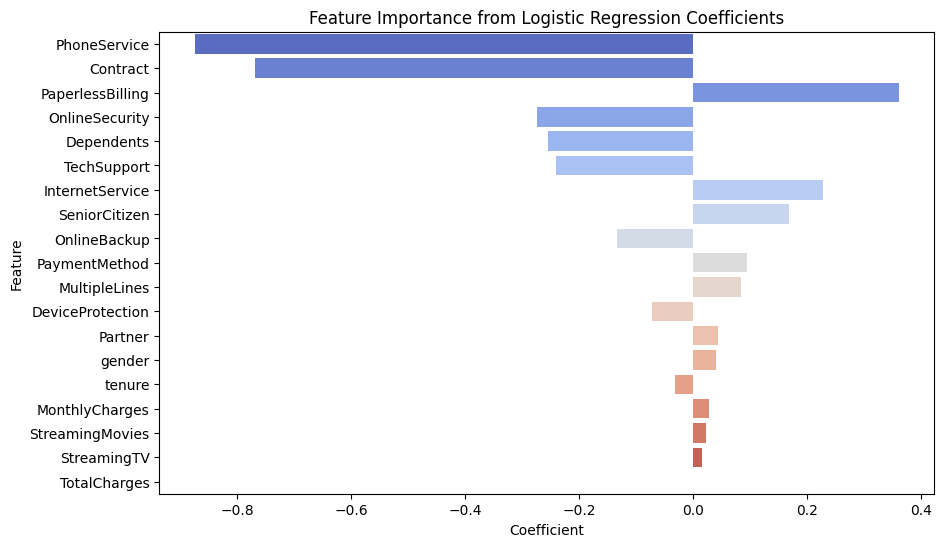

In [12]:
features = X.columns
coefficients = lr_model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients
})

coef_df['abs_coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coef', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm')
plt.title("Feature Importance from Logistic Regression Coefficients")
plt.show()

In [13]:
coef_table = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})
coef_table['Impact'] = coef_table['Coefficient'].apply(lambda x: 'High' if abs(x) > 0.1 else 'Low')
coef_table['Direction'] = coef_table['Coefficient'].apply(lambda x: 'Positive' if x > 0 else 'Negative')
coef_table['abs_coef'] = coef_table['Coefficient'].abs()
coef_table = coef_table.sort_values(by='abs_coef', ascending=False).drop(columns=['abs_coef'])

def color_coef(val):
    color = 'blue' if val > 0.1 else 'red' if val < -0.1 else 'lightgrey'
    return f'color: {color}'

coef_table.style.applymap(color_coef, subset=['Coefficient'])

/var/folders/rt/48gpknks5mlc888bjxc5dfx00000gn/T/ipykernel_1520/2129898090.py:14: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  coef_table.style.applymap(color_coef, subset=['Coefficient'])


,Feature,Coefficient,Impact,Direction
5,PhoneService,-0.875096,High,Negative
14,Contract,-0.769600,High,Negative
15,PaperlessBilling,0.362315,High,Positive
8,OnlineSecurity,-0.274640,High,Negative
3,Dependents,-0.254726,High,Negative
11,TechSupport,-0.240207,High,Negative
7,InternetService,0.229179,High,Positive
1,SeniorCitizen,0.169370,High,Positive
9,OnlineBackup,-0.133560,High,Negative
16,PaymentMethod,0.095481,Low,Positive


## 7. Misclassification Analysis (Failure Signals).

In [14]:
misclassified = X_test[y_test != y_pred].copy()
misclassified['Actual'] = y_test[y_test != y_pred]
misclassified['Predicted'] = y_pred[y_test != y_pred]

print("Number of misclassified samples:", misclassified.shape[0])
misclassified.head(10)


Number of misclassified samples: 363


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted
2280,0,1,0,0,8,1,2,1,0,0,...,2,2,2,0,1,1,100.15,6340,0,1
4460,1,0,1,0,18,1,0,1,0,0,...,2,0,0,0,0,2,78.20,862,0,1
5748,0,0,0,0,21,1,2,1,0,2,...,0,2,2,0,1,1,99.85,1599,0,1
3568,0,0,0,0,21,1,0,1,0,2,...,2,2,2,0,1,0,99.15,1558,0,1
2136,1,0,0,1,15,1,2,1,0,2,...,0,2,0,0,1,2,91.00,797,0,1
1838,1,1,0,0,54,1,2,1,0,2,...,0,0,2,0,1,2,90.05,4183,0,1
6979,1,0,0,1,1,0,1,0,0,0,...,0,0,0,0,0,3,24.20,2037,0,1
3624,0,1,1,1,62,1,2,1,0,2,...,0,0,2,0,1,1,96.10,4928,0,1
2488,1,0,0,0,31,1,0,0,0,0,...,2,0,0,0,1,2,55.25,1220,1,0
2519,1,0,1,0,2,1,2,1,0,0,...,0,2,0,0,1,2,91.45,1209,0,1


In [15]:
print("Total test samples:", len(y_test))
print("Misclassified samples:", misclassified.shape[0])
print("Percentage misclassified:", round(100 * misclassified.shape[0]/len(y_test), 2), "%")

# Next steps for failure analysis:
# 1. Investigate patterns in misclassified samples
# 2. Focus on high-impact features for explainability
# 3. Consider feature engineering or encoding improvements

Total test samples: 1409
Misclassified samples: 363
Percentage misclassified: 25.76 %


## 8. Day 1 Summary.

In [16]:
from IPython.display import display, Markdown

summary_text = """
# Day 1 — Baseline Analysis Summary

**Dataset Overview**
- Total features: 19 (excluding CustomerID)
- Target: Churn (Yes/No)
- Categorical features: 16
- Numeric features: 2 integers, 1 float
- Dataset is clean (no missing values)
- Target distribution is imbalanced (approx. 5000 No, 2000 Yes)

**EDA Insights**
- Many categorical features need encoding before modeling.
- Not all features may be useful — CustomerID dropped.
- Numeric summary only covers numeric columns; categorical distributions checked separately.
- Initial correlation patterns observed between some features and target.

**Baseline Model — Logistic Regression**
- Trained with `class_weight='balanced'` to handle imbalance.
- Performance on test set:
  - Confusion Matrix and Classification Report available
  - ROC-AUC calculated
- Feature importance:
  - 8 features with negative coefficients (reduce churn probability)
  - 10 features with positive coefficients (increase churn probability)
  - Only 4 positive features are high contributors (strong predictive power)

**Misclassified Samples**
- Number of misclassified samples and percentage displayed
- These samples will guide initial failure analysis.

**Next Steps**
1. Investigate misclassified patterns and feature contributions.
2. Consider advanced encoding / feature engineering.
3. Use insights to build model explainability and AI failure detection modules.
"""

display(Markdown(summary_text))


# Day 1 — Baseline Analysis Summary

**Dataset Overview**
- Total features: 19 (excluding CustomerID)
- Target: Churn (Yes/No)
- Categorical features: 16
- Numeric features: 2 integers, 1 float
- Dataset is clean (no missing values)
- Target distribution is imbalanced (approx. 5000 No, 2000 Yes)

**EDA Insights**
- Many categorical features need encoding before modeling.
- Not all features may be useful — CustomerID dropped.
- Numeric summary only covers numeric columns; categorical distributions checked separately.
- Initial correlation patterns observed between some features and target.

**Baseline Model — Logistic Regression**
- Trained with `class_weight='balanced'` to handle imbalance.
- Performance on test set:
  - Confusion Matrix and Classification Report available
  - ROC-AUC calculated
- Feature importance:
  - 8 features with negative coefficients (reduce churn probability)
  - 10 features with positive coefficients (increase churn probability)
  - Only 4 positive features are high contributors (strong predictive power)

**Misclassified Samples**
- Number of misclassified samples and percentage displayed
- These samples will guide initial failure analysis.

**Next Steps**
1. Investigate misclassified patterns and feature contributions.
2. Consider advanced encoding / feature engineering.
3. Use insights to build model explainability and AI failure detection modules.


## 9. Model Packaging and Saving.

In [17]:
from sklearn.pipeline import Pipeline
import joblib

# Create pipeline (model included)
pipeline = Pipeline([
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Train pipeline
pipeline.fit(X_train, y_train)

# Save pipeline
model_path = "../models/baseline_pipeline.pkl"
joblib.dump(pipeline, model_path)

print(f"Pipeline saved successfully at: {model_path}")

Pipeline saved successfully at: ../models/baseline_pipeline.pkl


/Users/rishikeshsingh/anaconda_projects/AI_Model_Failure_Detection/ai-model-failure-detection/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Verify Saved Model.

In [18]:
loaded_pipeline = joblib.load("../models/baseline_pipeline.pkl")

test_preds = loaded_pipeline.predict(X_test[:5])

print("Sample predictions from loaded pipeline:", test_preds)

Sample predictions from loaded pipeline: [0 1 0 1 0]
